<a href="https://colab.research.google.com/github/harish0785/160-Gbps-OCDMA-FSO-Simulator/blob/main/CAPSTONE_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "ray[rllib]" gymnasium numpy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 10.7 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.3
    Uninstalling gymnasium-1.2.3:
      Successfully uninstalled gymnasium-1.2.3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

import ray
from ray.rllib.env.multi_agent_env import MultiAgentEnv

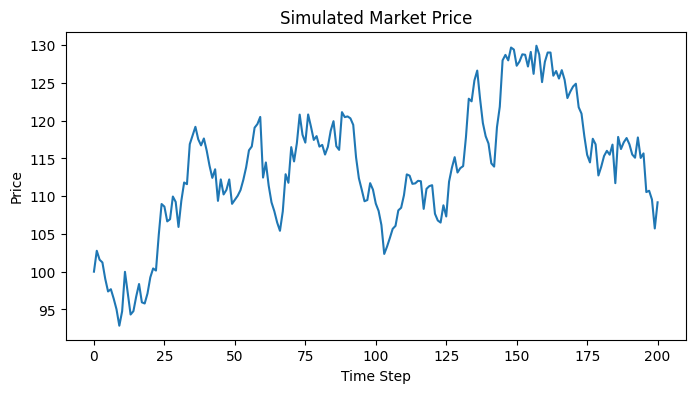

In [3]:
# Market Price Simulation using Geometric Brownian Motion

initial_price = 100
mu = 0.001       # expected return
sigma = 0.02     # volatility
steps = 200

prices = [initial_price]

for t in range(steps):

    dt = 1
    shock = np.random.normal(0,1)

    new_price = prices[-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*shock*np.sqrt(dt))

    prices.append(new_price)

# Plot simulated price movement
plt.figure(figsize=(8,4))
plt.plot(prices)
plt.title("Simulated Market Price")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.show()

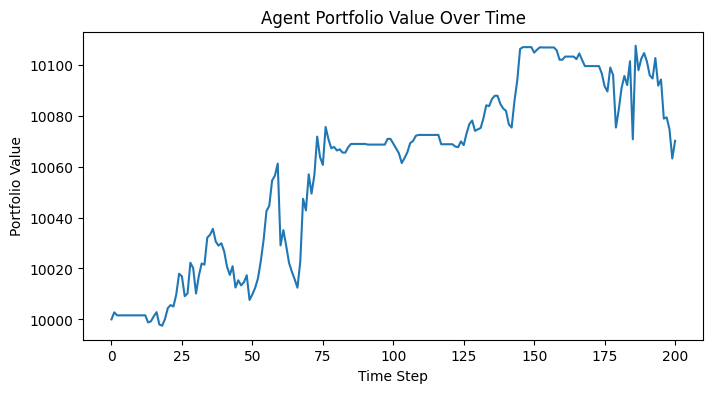

In [4]:
# Trading simulation (single agent prototype)

cash = 10000
shares = 0

portfolio_values = []

for price in prices:

    action = np.random.choice([0,1,2])

    # 0 = Hold
    # 1 = Buy
    # 2 = Sell

    if action == 1:  # BUY
        if cash >= price:
            shares += 1
            cash -= price

    elif action == 2:  # SELL
        if shares > 0:
            shares -= 1
            cash += price

    portfolio_value = cash + shares * price
    portfolio_values.append(portfolio_value)

# Plot portfolio value
plt.figure(figsize=(8,4))
plt.plot(portfolio_values)
plt.title("Agent Portfolio Value Over Time")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.show()

In [7]:
env = MarketEnv()

state, _ = env.reset()

for i in range(10):

    action = env.action_space.sample()

    state, reward, terminated, truncated, _ = env.step(action)

    print("State:", state)
    print("Reward:", reward)

NameError: name 'MarketEnv' is not defined

In [ ]:
class MarketEnv(gym.Env):

    def __init__(self, env_config=None):
        super(MarketEnv, self).__init__()

        # Action space
        # 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Discrete(3)

        # Observation space
        # [price, cash, shares, timestep]
        self.observation_space = spaces.Box(
            low=0,
            high=100000,
            shape=(4,),
            dtype=np.float32
        )

        self.initial_cash = 10000
        self.max_steps = 200

        self.reset()

    def reset(self, seed=None, options=None):

        self.price = 100
        self.cash = self.initial_cash
        self.shares = 0
        self.step_count = 0

        state = np.array([
            self.price,
            self.cash,
            self.shares,
            self.step_count
        ], dtype=np.float32)

        return state, {}

    def step(self, action):

        self.step_count += 1

        # BUY
        if action == 1:
            if self.cash >= self.price:
                self.cash -= self.price
                self.shares += 1

        # SELL
        elif action == 2:
            if self.shares > 0:
                self.cash += self.price
                self.shares -= 1

        # Market price movement (Geometric Brownian Motion)
        mu = 0.001
        sigma = 0.02
        shock = np.random.normal()

        self.price = self.price * np.exp((mu - 0.5*sigma**2) + sigma * shock)

        portfolio_value = self.cash + self.shares * self.price

        reward = portfolio_value / 10000

        state = np.array([
            self.price,
            self.cash,
            self.shares,
            self.step_count
        ], dtype=np.float32)

        terminated = False
        truncated = self.step_count >= self.max_steps

        return state, reward, terminated, truncated, {}

In [ ]:
env = MarketEnv()

state, _ = env.reset()

for i in range(5):

    action = env.action_space.sample()

    state, reward, terminated, truncated, _ = env.step(action)

    print("State:", state)
    print("Reward:", reward)

In [ ]:
from ray.rllib.algorithms.ppo import PPOConfig
import ray

# Start Ray runtime
ray.init(ignore_reinit_error=True)

# Configure PPO training
config = (
    PPOConfig()
    .environment(env=MarketEnv)
    .framework("torch")
    .env_runners(num_env_runners=0)
)

# Build the RL algorithm
algo = config.build()

print("RL training system initialized successfully.")

In [ ]:
training_rewards = []

for i in range(20):

    result = algo.train()

    # Safely extract reward
    reward = result.get("episode_return_mean", None)

    if reward is None:
        reward = result.get("env_runners", {}).get("episode_return_mean", 0)

    training_rewards.append(reward)

    print("Iteration:", i, "| Mean Reward:", reward)

In [ ]:
import torch

module = algo.get_module()

env = MarketEnv()
state, _ = env.reset()

prices = []
portfolio_values = []

done = False

while not done:

    obs_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

    batch = {"obs": obs_tensor}

    output = module.forward_inference(batch)

    # Get logits from policy
    logits = output["action_dist_inputs"]

    # Convert logits to probability distribution
    action = torch.argmax(logits, dim=1).item()

    state, reward, terminated, truncated, _ = env.step(action)

    price = state[0]
    cash = state[1]
    shares = state[2]

    portfolio_value = cash + shares * price

    prices.append(price)
    portfolio_values.append(portfolio_value)

    done = terminated or truncated

In [ ]:
plt.plot(prices)
plt.title("Market Price Evolution")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.show()

In [ ]:
plt.plot(portfolio_values)
plt.title("Agent Portfolio Value")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.show()

In [ ]:
from ray.rllib.env.multi_agent_env import MultiAgentEnv
from gymnasium import spaces
import numpy as np

class MultiAgentMarketEnv(MultiAgentEnv):

    def __init__(self, env_config=None):

        super().__init__()

        # Number of agents
        self.n_agents = 5
        self.agent_ids = [f"agent_{i}" for i in range(self.n_agents)]

        self.initial_cash = 10000
        self.max_steps = 200

        # Action space
        # 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Discrete(3)

        # Observation space
        self.observation_space = spaces.Box(
            low=0,
            high=100000,
            shape=(4,),
            dtype=np.float32
        )

        self.reset()


    def reset(self, *, seed=None, options=None):

        self.price = 100
        self.step_count = 0

        self.cash = {agent: self.initial_cash for agent in self.agent_ids}
        self.shares = {agent: 0 for agent in self.agent_ids}

        observations = {}

        for agent in self.agent_ids:
            observations[agent] = np.array([
                self.price,
                self.cash[agent],
                self.shares[agent],
                self.step_count
            ], dtype=np.float32)

        return observations, {}


    def step(self, actions):

        self.step_count += 1

        rewards = {}
        observations = {}
        terminated = {}
        truncated = {}
        infos = {}

        # Execute agent actions
        for agent, action in actions.items():

            if action == 1:  # BUY
                if self.cash[agent] >= self.price:
                    self.cash[agent] -= self.price
                    self.shares[agent] += 1

            elif action == 2:  # SELL
                if self.shares[agent] > 0:
                    self.cash[agent] += self.price
                    self.shares[agent] -= 1

        # Market price movement (GBM model)
        mu = 0.001
        sigma = 0.02
        shock = np.random.normal()

        self.price = self.price * np.exp((mu - 0.5 * sigma**2) + sigma * shock)

        # Update agent observations and rewards
        for agent in self.agent_ids:

            portfolio_value = self.cash[agent] + self.shares[agent] * self.price

            rewards[agent] = portfolio_value / 10000

            observations[agent] = np.array([
                self.price,
                self.cash[agent],
                self.shares[agent],
                self.step_count
            ], dtype=np.float32)

            terminated[agent] = False
            truncated[agent] = self.step_count >= self.max_steps
            infos[agent] = {}

        terminated["__all__"] = False
        truncated["__all__"] = self.step_count >= self.max_steps

        return observations, rewards, terminated, truncated, infos

In [ ]:
env = MultiAgentMarketEnv()

obs, _ = env.reset()

for i in range(3):

    actions = {}

    for agent in obs:
        actions[agent] = env.action_space.sample()

    obs, rewards, terminated, truncated, _ = env.step(actions)

    print("Rewards:", rewards)

In [ ]:
!pip install "ray[rllib]" gymnasium numpy matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

import ray
from ray.rllib.env.multi_agent_env import MultiAgentEnv
from ray.rllib.algorithms.ppo import PPOConfig

In [ ]:
class MultiAgentMarketEnv(MultiAgentEnv):

    def __init__(self, env_config=None):

        super().__init__()

        self.n_agents = 5
        self.agent_ids = [f"agent_{i}" for i in range(self.n_agents)]

        self.initial_cash = 10000
        self.max_steps = 200

        # Observation space for each agent
        obs_space = spaces.Box(
            low=0,
            high=100000,
            shape=(4,),
            dtype=np.float32
        )

        # Action space
        act_space = spaces.Discrete(3)

        self.observation_space = spaces.Dict({
            agent: obs_space for agent in self.agent_ids
        })

        self.action_space = spaces.Dict({
            agent: act_space for agent in self.agent_ids
        })

        self.reset()

    def reset(self, *, seed=None, options=None):

        self.price = 100
        self.step_count = 0

        self.cash = {agent: self.initial_cash for agent in self.agent_ids}
        self.shares = {agent: 0 for agent in self.agent_ids}

        obs = {}

        for agent in self.agent_ids:

            obs[agent] = np.array([
                self.price,
                self.cash[agent],
                self.shares[agent],
                self.step_count
            ], dtype=np.float32)

        return obs, {}

    def step(self, actions):

        self.step_count += 1

        rewards = {}
        obs = {}
        terminated = {}
        truncated = {}
        infos = {}

        # Execute actions
        for agent, action in actions.items():

            if action == 1:  # BUY
                if self.cash[agent] >= self.price:
                    self.cash[agent] -= self.price
                    self.shares[agent] += 1

            elif action == 2:  # SELL
                if self.shares[agent] > 0:
                    self.cash[agent] += self.price
                    self.shares[agent] -= 1

        # Market price dynamics (Geometric Brownian Motion)
        mu = 0.001
        sigma = 0.02
        shock = np.random.normal()

        self.price = self.price * np.exp((mu - 0.5 * sigma**2) + sigma * shock)

        for agent in self.agent_ids:

            portfolio_value = self.cash[agent] + self.shares[agent] * self.price

            rewards[agent] = portfolio_value / 10000

            obs[agent] = np.array([
                self.price,
                self.cash[agent],
                self.shares[agent],
                self.step_count
            ], dtype=np.float32)

            terminated[agent] = False
            truncated[agent] = self.step_count >= self.max_steps
            infos[agent] = {}

        terminated["__all__"] = False
        truncated["__all__"] = self.step_count >= self.max_steps

        return obs, rewards, terminated, truncated, infos

In [ ]:
ray.init(ignore_reinit_error=True)

In [ ]:
env = MultiAgentMarketEnv()

policies = {
    "trading_policy": (
        None,
        spaces.Box(low=0, high=100000, shape=(4,), dtype=np.float32),
        spaces.Discrete(3),
        {}
    )
}

def policy_mapping_fn(agent_id, *args, **kwargs):
    return "trading_policy"

config = (
    PPOConfig()
    .environment(env=MultiAgentMarketEnv)
    .framework("torch")
    .env_runners(num_env_runners=0)
    .multi_agent(
        policies=policies,
        policy_mapping_fn=policy_mapping_fn
    )
)

algo = config.build()

print("Multi-Agent RL system initialized")

In [ ]:
training_rewards = []

for i in range(20):

    result = algo.train()

    reward = result.get("episode_return_mean", None)

    if reward is None:
        reward = result.get("env_runners", {}).get("episode_return_mean", 0)

    training_rewards.append(reward)

    print("Iteration:", i, "| Mean Market Reward:", reward)

In [ ]:
plt.plot(training_rewards)
plt.title("Training Reward Progress")
plt.xlabel("Iteration")
plt.ylabel("Reward")
plt.show()

In [ ]:
plt.plot(training_rewards)
plt.title("Training Reward Progress")
plt.xlabel("Iteration")
plt.ylabel("Reward")
plt.show()

In [ ]:
import torch

env = MultiAgentMarketEnv()

obs, _ = env.reset()

module = algo.get_module("trading_policy")

price_history = []
agent_portfolios = {agent: [] for agent in env.agent_ids}

done = False

while not done:

    actions = {}

    for agent in obs:

        obs_tensor = torch.tensor(obs[agent], dtype=torch.float32).unsqueeze(0)

        batch = {"obs": obs_tensor}

        output = module.forward_inference(batch)

        logits = output["action_dist_inputs"]

        action = torch.argmax(logits, dim=1).item()

        actions[agent] = action

    obs, rewards, terminated, truncated, _ = env.step(actions)

    price_history.append(env.price)

    for agent in env.agent_ids:
        portfolio_value = env.cash[agent] + env.shares[agent] * env.price
        agent_portfolios[agent].append(portfolio_value)

    done = truncated["__all__"]

In [ ]:
plt.plot(price_history)
plt.title("Market Price Evolution")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.show()

In [ ]:
for agent, values in agent_portfolios.items():
    plt.plot(values, label=agent)

plt.title("Agent Portfolio Performance")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

In [ ]:
actions = {}

for agent in obs:

    if agent == "agent_0":
        # RL agent
        obs_tensor = torch.tensor(obs[agent], dtype=torch.float32).unsqueeze(0)
        batch = {"obs": obs_tensor}
        output = module.forward_inference(batch)
        logits = output["action_dist_inputs"]
        action = torch.argmax(logits, dim=1).item()

    elif agent == "agent_1":
        # Momentum trader
        if len(price_history) > 1 and price_history[-1] > price_history[-2]:
            action = 1  # Buy
        else:
            action = 0  # Hold

    elif agent == "agent_2":
        # Mean reversion trader
        if len(price_history) > 5:
            avg_price = np.mean(price_history[-5:])
            if env.price < avg_price:
                action = 1
            else:
                action = 2
        else:
            action = 0

    elif agent == "agent_3":
        # Random trader
        action = np.random.choice([0,1,2])

    else:
        # Risk-averse trader
        if env.price > 105:
            action = 2
        else:
            action = 0

    actions[agent] = action

In [ ]:
class MultiAgentMarketEnv(MultiAgentEnv):

    def __init__(self, env_config=None):
        super().__init__()

        self.n_agents = 5
        self.agent_ids = [f"agent_{i}" for i in range(self.n_agents)]

        self.initial_cash = 10000
        self.max_steps = 200

        self.price = 100

In [ ]:
def step(self, actions):

    self.step_count += 1

    rewards = {}
    obs = {}
    terminated = {}
    truncated = {}
    infos = {}

    # Execute trading actions
    for agent, action in actions.items():

        if action == 1 and self.cash[agent] >= self.price:
            self.cash[agent] -= self.price
            self.shares[agent] += 1

        elif action == 2 and self.shares[agent] > 0:
            self.cash[agent] += self.price
            self.shares[agent] -= 1


    # -------- MARKET PRICE DYNAMICS --------

    regime = np.random.choice(["bull","bear","volatile"])

    if regime == "bull":
        mu = 0.003
        sigma = 0.02

    elif regime == "bear":
        mu = -0.003
        sigma = 0.02

    else:
        mu = 0.0
        sigma = 0.05

    shock = np.random.normal()

    self.price = self.price * np.exp((mu - 0.5*sigma**2) + sigma*shock)


    # --------------------------------------

    for agent in self.agent_ids:

        portfolio_value = self.cash[agent] + self.shares[agent] * self.price

        rewards[agent] = portfolio_value / 10000

        obs[agent] = np.array([
            self.price,
            self.cash[agent],
            self.shares[agent],
            self.step_count
        ], dtype=np.float32)

        terminated[agent] = False
        truncated[agent] = self.step_count >= self.max_steps
        infos[agent] = {}

    terminated["__all__"] = False
    truncated["__all__"] = self.step_count >= self.max_steps

    return obs, rewards, terminated, truncated, infos

In [ ]:
def step(self, actions):

    self.step_count += 1

    rewards = {}
    obs = {}
    terminated = {}
    truncated = {}
    infos = {}

    # Execute trading actions
    for agent, action in actions.items():

        if action == 1 and self.cash[agent] >= self.price:
            self.cash[agent] -= self.price
            self.shares[agent] += 1

        elif action == 2 and self.shares[agent] > 0:
            self.cash[agent] += self.price
            self.shares[agent] -= 1


    # -------- MARKET PRICE DYNAMICS --------

    regime = np.random.choice(["bull","bear","volatile"])

    if regime == "bull":
        mu = 0.003
        sigma = 0.02

    elif regime == "bear":
        mu = -0.003
        sigma = 0.02

    else:
        mu = 0.0
        sigma = 0.05

    shock = np.random.normal()

    self.price = self.price * np.exp((mu - 0.5*sigma**2) + sigma*shock)


    # --------------------------------------

    for agent in self.agent_ids:

        portfolio_value = self.cash[agent] + self.shares[agent] * self.price

        rewards[agent] = portfolio_value / 10000

        obs[agent] = np.array([
            self.price,
            self.cash[agent],
            self.shares[agent],
            self.step_count
        ], dtype=np.float32)

        terminated[agent] = False
        truncated[agent] = self.step_count >= self.max_steps
        infos[agent] = {}

    terminated["__all__"] = False
    truncated["__all__"] = self.step_count >= self.max_steps

    return obs, rewards, terminated, truncated, infos

In [ ]:
final_results = {}

for agent in env.agent_ids:

    final_portfolio = env.cash[agent] + env.shares[agent] * env.price

    profit = final_portfolio - env.initial_cash

    final_results[agent] = {
        "final_portfolio": final_portfolio,
        "profit": profit
    }

print(final_results)

In [ ]:
leaderboard = sorted(
    final_results.items(),
    key=lambda x: x[1]["profit"],
    reverse=True
)

for rank, (agent, data) in enumerate(leaderboard, start=1):

    print(
        f"Rank {rank}: {agent} | "
        f"Profit: {data['profit']:.2f} | "
        f"Final Portfolio: {data['final_portfolio']:.2f}"
    )

In [ ]:
agents = list(final_results.keys())
profits = [final_results[a]["profit"] for a in agents]

plt.bar(agents, profits)
plt.title("Agent Profit Comparison")
plt.xlabel("Agent")
plt.ylabel("Profit")
plt.show()

In [ ]:
import pandas as pd

data = []

for agent in env.agent_ids:

    portfolio = env.cash[agent] + env.shares[agent] * env.price

    profit = portfolio - env.initial_cash

    data.append({
        "Agent": agent,
        "Final Portfolio": portfolio,
        "Profit": profit
    })

df = pd.DataFrame(data)

df

In [ ]:
plt.figure(figsize=(8,4))

plt.bar(df["Agent"], df["Profit"])

plt.title("Agent Profit Leaderboard")
plt.xlabel("Agent")
plt.ylabel("Profit")

plt.show()

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(price_history)

plt.title("Simulated Market Price")
plt.xlabel("Time Step")
plt.ylabel("Price")

plt.show()

In [ ]:
plt.figure(figsize=(8,4))

for agent, values in agent_portfolios.items():
    plt.plot(values, label=agent)

plt.title("Portfolio Growth of Agents")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

In [ ]:
class MultiAgentMarketEnv(MultiAgentEnv):

    def __init__(self, env_config=None):

        self.price = 100
        self.initial_cash = 10000
        self.max_steps = 200


    def step(self, actions):

        self.step_count += 1

        # agents trade here...

        # price dynamics here
        regime = np.random.choice(["bull","bear","volatile"])

        if regime == "bull":
            mu = 0.003
            sigma = 0.02
        elif regime == "bear":
            mu = -0.003
            sigma = 0.02
        else:
            mu = 0.0
            sigma = 0.05

        shock = np.random.normal()

        self.price = self.price * np.exp((mu - 0.5*sigma**2) + sigma*shock)

In [ ]:
price = 100
price = price * np.exp((mu - 0.5*sigma**2) + sigma*shock)

In [ ]:
!pip install streamlit

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Multi-Agent Reinforcement Learning Market Simulator")

# --- Leaderboard Data ---

data = {
    "Agent": [],
    "Final Portfolio": [],
    "Profit": []
}

for agent in env.agent_ids:

    portfolio = env.cash[agent] + env.shares[agent] * env.price
    profit = portfolio - env.initial_cash

    data["Agent"].append(agent)
    data["Final Portfolio"].append(portfolio)
    data["Profit"].append(profit)

df = pd.DataFrame(data)

st.subheader("Agent Leaderboard")
st.dataframe(df.sort_values(by="Profit", ascending=False))

# --- Profit Chart ---

st.subheader("Profit Comparison")

fig, ax = plt.subplots()
ax.bar(df["Agent"], df["Profit"])
ax.set_xlabel("Agent")
ax.set_ylabel("Profit")
ax.set_title("Agent Profit Comparison")

st.pyplot(fig)

# --- Market Price ---

st.subheader("Market Price Evolution")

fig2, ax2 = plt.subplots()
ax2.plot(price_history)
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Price")

st.pyplot(fig2)